In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("flights.csv")

print(df.shape)
print(df.head())
print(df.columns)

(10000, 660)
   MONTH  DAY_OF_WEEK  DISTANCE  SCHEDULED_DEPARTURE  ARRIVAL_DELAY  \
0      2            4      1608                  148              1   
1      7            2      1491                 2105              1   
2      2            6       247                 2150              1   
3      7            6       382                 1535              0   
4      8            6       468                  925              0   

   AIRLINE_AS  AIRLINE_B6  AIRLINE_DL  AIRLINE_EV  AIRLINE_F9  ...  \
0       False       False       False       False       False  ...   
1       False       False       False       False       False  ...   
2       False       False       False       False       False  ...   
3       False       False       False       False       False  ...   
4       False       False       False       False       False  ...   

   DESTINATION_AIRPORT_TYS  DESTINATION_AIRPORT_UST  DESTINATION_AIRPORT_VEL  \
0                    False                    False        

In [39]:
import numpy as np

X = np.array([[1,1],[0,1],[1,0],[0,0]])
Y = np.array([2,1,1,2])
lam = 1

I = np.eye(X.shape[1])

theta = np.linalg.inv(X.T @ X + lam*I) @ X.T @ Y

print(theta)

[0.75 0.75]


In [41]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.random.uniform(-2,2,1000)
e = np.random.normal(0,2,1000)
Y = 1 + 2*X + e

from sklearn.linear_model import LinearRegression, Ridge

X = X.reshape(-1,1)

lin = LinearRegression()
lin.fit(X,Y)

ridge_results = []

for lam in [1,10,100,1000,10000]:
    ridge = Ridge(alpha=lam)
    ridge.fit(X,Y)
    y_pred = ridge.predict(X)

    from sklearn.metrics import mean_squared_error, r2_score

    mse = mean_squared_error(Y, y_pred)
    r2 = r2_score(Y, y_pred)

    ridge_results.append((lam, ridge.coef_[0], mse, r2))

print("Linear slope:", lin.coef_[0])

for r in ridge_results:
    print(r)

Linear slope: 1.9226074184723272
(1, 1.921199061693204, 3.8998742328515537, 0.5638853127446299)
(10, 1.9086160915718275, 3.9001385678344787, 0.563855752722556)
(100, 1.791294539043563, 3.9233935315005146, 0.5612551993198549)
(1000, 1.1093706623247752, 4.802052525912095, 0.46299662233191574)
(10000, 0.23078821468112398, 7.80439086317996, 0.12725147599805886)


In [10]:
df = pd.read_csv("flights.csv")

print(df.shape)
print(df.columns[:20])

(10000, 660)
Index(['MONTH', 'DAY_OF_WEEK', 'DISTANCE', 'SCHEDULED_DEPARTURE',
       'ARRIVAL_DELAY', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV',
       'AIRLINE_F9', 'AIRLINE_HA', 'AIRLINE_MQ', 'AIRLINE_NK', 'AIRLINE_OO',
       'AIRLINE_UA', 'AIRLINE_US', 'AIRLINE_VX', 'AIRLINE_WN',
       'ORIGIN_AIRPORT_ABI', 'ORIGIN_AIRPORT_ABQ'],
      dtype='object')


In [12]:
target = "ARRIVAL_DELAY"

X = df.drop(columns=[target])
y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(X_train.shape, X_test.shape)

(7500, 659) (2500, 659)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
 [[707 544]
 [502 747]]
Accuracy: 0.5816
Precision: 0.5786212238574748
Recall: 0.5980784627702161
F1 Score: 0.5881889763779529


In [21]:
coefficients = model.coef_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by importance
coef_df_sorted = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df_sorted.head(10))   # top positive
print("------")
print(coef_df_sorted.tail(10))   # top negative

                     Feature  Coefficient
3        SCHEDULED_DEPARTURE     0.437004
654  DESTINATION_AIRPORT_WRG     0.199250
497  DESTINATION_AIRPORT_ISP     0.158384
95        ORIGIN_AIRPORT_CWA     0.155523
16                AIRLINE_WN     0.143571
74        ORIGIN_AIRPORT_CHA     0.137873
35        ORIGIN_AIRPORT_ASE     0.135199
625  DESTINATION_AIRPORT_SMX     0.132361
7                 AIRLINE_EV     0.131577
345  DESTINATION_AIRPORT_ACY     0.131392
------
                     Feature  Coefficient
628  DESTINATION_AIRPORT_SPS    -0.129386
187       ORIGIN_AIRPORT_KTN    -0.136234
321       ORIGIN_AIRPORT_TTN    -0.142551
483  DESTINATION_AIRPORT_HSV    -0.148463
658  DESTINATION_AIRPORT_YUM    -0.148842
506  DESTINATION_AIRPORT_JNU    -0.154570
524  DESTINATION_AIRPORT_LRD    -0.156438
218       ORIGIN_AIRPORT_MHT    -0.160249
133       ORIGIN_AIRPORT_FSM    -0.170598
338  DESTINATION_AIRPORT_ABI    -0.222196


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_probs = model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.25, 0.5, 0.75, 0.9]

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)

    print(f"Threshold: {t}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("------")

Threshold: 0.25
Accuracy: 0.5284
Precision: 0.5151122625215889
Recall: 0.9551641313050441
------
Threshold: 0.5
Accuracy: 0.5816
Precision: 0.5786212238574748
Recall: 0.5980784627702161
------
Threshold: 0.75
Accuracy: 0.5152
Precision: 0.5968586387434555
Recall: 0.09127301841473179
------
Threshold: 0.9
Accuracy: 0.5052
Precision: 0.65
Recall: 0.020816653322658127
------


In [27]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Gradient Descent for Logistic Regression
def gradient_descent_logistic(X, y, alpha, iterations):
    m = len(y)
    
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros(X_b.shape[1])

    losses = []

    for i in range(iterations):
        z = X_b @ theta
        h = sigmoid(z)

        gradients = (1/m) * X_b.T @ (h - y)
        theta -= alpha * gradients

        # Cross-entropy loss
        loss = -np.mean(y*np.log(h + 1e-8) + (1-y)*np.log(1-h + 1e-8))
        losses.append(loss)

    return theta, losses

In [29]:
results_logistic_gd = []

for alpha in [0.1, 0.01, 0.001]:
    for iters in [10, 50, 100]:
        theta_gd, losses = gradient_descent_logistic(X_train_scaled, y_train.values, alpha, iters)

        X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
        X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

        train_preds = (sigmoid(X_train_b @ theta_gd) >= 0.5).astype(int)
        test_preds = (sigmoid(X_test_b @ theta_gd) >= 0.5).astype(int)

        train_loss = losses[-1]

        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

        acc = accuracy_score(y_test, test_preds)
        prec = precision_score(y_test, test_preds)
        rec = recall_score(y_test, test_preds)
        f1 = f1_score(y_test, test_preds)

        results_logistic_gd.append((alpha, iters, train_loss, acc, prec, rec, f1))

for r in results_logistic_gd:
    print(r)

(0.1, 10, 0.6665720463542674, 0.5712, 0.5673003802281369, 0.5972778222578062, 0.5819032761310452)
(0.1, 50, 0.6300345550637066, 0.5776, 0.5752143413873734, 0.5908726981585268, 0.5829383886255924)
(0.1, 100, 0.6220141793693397, 0.5776, 0.5753317720530835, 0.5900720576461169, 0.5826086956521739)
(0.01, 10, 0.6897833080928584, 0.5712, 0.5671981776765376, 0.5980784627702161, 0.5822291504286826)
(0.01, 50, 0.6770011572187025, 0.5708, 0.5668693009118541, 0.5972778222578062, 0.5816764132553606)
(0.01, 100, 0.6649334968849495, 0.5712, 0.5673003802281369, 0.5972778222578062, 0.5819032761310452)
(0.001, 10, 0.6928022147489064, 0.5708, 0.5667678300455236, 0.5980784627702161, 0.5820023373587846)
(0.001, 50, 0.691293684400657, 0.5708, 0.5667678300455236, 0.5980784627702161, 0.5820023373587846)
(0.001, 100, 0.6894630368150062, 0.5712, 0.5671981776765376, 0.5980784627702161, 0.5822291504286826)


In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Models
knn = KNeighborsClassifier(n_neighbors=5)
log_reg = LogisticRegression(max_iter=1000)
lda = LinearDiscriminantAnalysis()

# Train
knn.fit(X_train_scaled, y_train)
log_reg.fit(X_train_scaled, y_train)
lda.fit(X_train_scaled, y_train)

# Predictions
knn_pred = knn.predict(X_test_scaled)
log_pred = log_reg.predict(X_test_scaled)
lda_pred = lda.predict(X_test_scaled)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    )

print("kNN:", get_metrics(y_test, knn_pred))
print("Logistic:", get_metrics(y_test, log_pred))
print("LDA:", get_metrics(y_test, lda_pred))

kNN: (0.5148, 0.513677811550152, 0.5412329863891113, 0.5270955165692008)
Logistic: (0.5816, 0.5786212238574748, 0.5980784627702161, 0.5881889763779529)
LDA: (0.5792, 0.5758275596612779, 0.5988791032826261, 0.58712715855573)


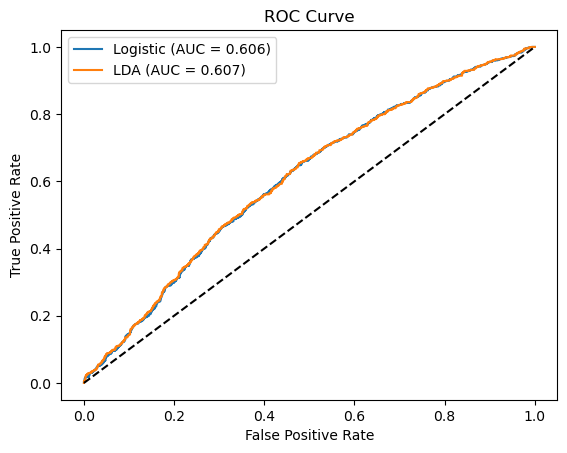

Logistic AUC: 0.6058333477333426
LDA AUC: 0.607202948609887


In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression
log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
auc_log = auc(fpr_log, tpr_log)

# LDA
lda_probs = lda.predict_proba(X_test_scaled)[:, 1]
fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_probs)
auc_lda = auc(fpr_lda, tpr_lda)

# Plot
plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_lda, tpr_lda, label=f"LDA (AUC = {auc_lda:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("Logistic AUC:", auc_log)
print("LDA AUC:", auc_lda)

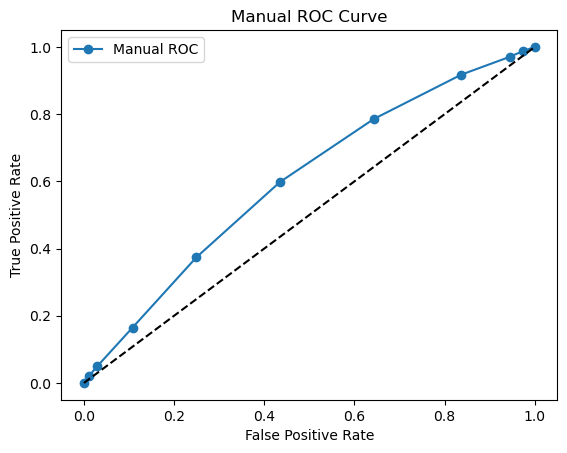

In [37]:
thresholds = np.linspace(0, 1, 11)

fpr_list = []
tpr_list = []

for t in thresholds:
    y_pred_t = (log_probs >= t).astype(int)

    TP = np.sum((y_test == 1) & (y_pred_t == 1))
    FP = np.sum((y_test == 0) & (y_pred_t == 1))
    TN = np.sum((y_test == 0) & (y_pred_t == 0))
    FN = np.sum((y_test == 1) & (y_pred_t == 0))

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    tpr_list.append(TPR)
    fpr_list.append(FPR)

# Plot manual ROC
plt.figure()
plt.plot(fpr_list, tpr_list, marker='o', label="Manual ROC")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve")
plt.legend()
plt.show()

In [44]:
from sklearn.model_selection import KFold

def cross_val_error(model, X, y, k):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    errors = []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        error = 1 - accuracy_score(y_val, preds)
        errors.append(error)

    return np.mean(errors)


# Logistic + LDA
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

for k in [5,10]:
    log_err = cross_val_error(LogisticRegression(max_iter=1000), X_train_scaled, y_train.values, k)
    lda_err = cross_val_error(LinearDiscriminantAnalysis(), X_train_scaled, y_train.values, k)

    print(f"K={k} Logistic Error:", log_err)
    print(f"K={k} LDA Error:", lda_err)

for k in [10]:
    log_err = cross_val_error(LogisticRegression(max_iter=1000), X_train_scaled, y_train.values, k)
    lda_err = cross_val_error(LinearDiscriminantAnalysis(), X_train_scaled, y_train.values, k)

    print(f"K={k} Logistic Error:", log_err)
    print(f"K={k} LDA Error:", lda_err)

KeyboardInterrupt: 

In [47]:
from sklearn.model_selection import cross_val_score

for k in [5, 10]:
    log_scores = cross_val_score(LogisticRegression(max_iter=1000), X_train_scaled, y_train, cv=k)
    lda_scores = cross_val_score(LinearDiscriminantAnalysis(), X_train_scaled, y_train, cv=k)

    print(f"K={k} Logistic Error:", 1 - log_scores.mean())
    print(f"K={k} LDA Error:", 1 - lda_scores.mean())

K=5 Logistic Error: 0.41680000000000006
K=5 LDA Error: 0.4709333333333333
K=10 Logistic Error: 0.4197333333333334
K=10 LDA Error: 0.48586666666666667
